# M4 — A+B+C 결합 모델 + RQ2 검증 (XGBoost)

**모델 정의**

| 모델 | X | 변수 | 역할 |
|---|---|---|---|
| M3 | A + B | 49 | 금융 + 전통 비금융 (기준) |
| M4 | A + B + C | 64 | 거기에 신규 비금융(C) 추가 |

**RQ2 검증**

M4 vs M3 의 AUC 차이 = **C(신규 비금융)의 순수 추가 기여**
C만 넣고 뺐으므로(A·B는 공통) 차이가 순수하게 C 효과다.
DeLong 검정으로 그 차이가 유의한지 판정한다.

**왜 A+C vs A+B 가 아니라 A+B+C vs A+B 인가**

RQ2 는 "신규가 **추가로** 기여하는가" 를 묻는다.
C만 넣고 빼야 순수 기여가 나온다.
A+C vs A+B 는 B를 C로 **교체**한 것이라 B와 C의 우열 비교가 되어버려
RQ2 와 다른 질문이 된다.

**입력** — `model_A_financial_final.csv` / `model_B_nonfinancial_final.csv` /
`model_C_nonfinancial_new_final.csv`

**출력** — `results_M4.csv` / `delong_M4.csv` / `importance_M4_ABC.csv`

실행 시간은 Colab 기준 약 9분.

## 0. 설정

In [2]:
!pip install xgboost -q

import os, warnings, time, gc
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from scipy import stats
import xgboost as xgb
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

SRC = '/content/drive/MyDrive/BOOSTMAP/데이터/완료/재계산'
OUT = f'{SRC}/모델링'
os.makedirs(OUT, exist_ok=True)

FILE_A = f'{SRC}/model_A_financial_final.csv'
FILE_B = f'{SRC}/model_B_nonfinancial_final.csv'
FILE_C = f'{SRC}/model_C_nonfinancial_new_final.csv'

N_FOLDS = 5           # 최종 5, 빠른 테스트 3
SAMPLE_N = None       # None=전체 30만, 빠른 테스트는 150000
RANDOM_STATE = 42
EARLY_STOP = 80
ID, TARGET = 'SK_ID_CURR', 'TARGET'

print('xgboost', xgb.__version__, '| 출력 ->', OUT)

Mounted at /content/drive
xgboost 3.3.0 | 출력 -> /content/drive/MyDrive/BOOSTMAP/데이터/완료/재계산/모델링


## 1. 로드 & 병합

- `bool` 컬럼은 `int` 로 변환한다
- 비수치 컬럼(`AGE_BAND` 등)은 `is_numeric_dtype` 으로 자동 제외한다

In [3]:
A = pd.read_csv(FILE_A)
B = pd.read_csv(FILE_B)
C = pd.read_csv(FILE_C)

a_cols = [c for c in A.columns if c not in (ID, TARGET)]
b_cols = [c for c in B.columns if c not in (ID, TARGET)]
c_cols = [c for c in C.columns if c not in (ID, TARGET)]

df = A.merge(B[[ID] + b_cols], on=ID, how='inner')
df = df.merge(C[[ID] + c_cols], on=ID, how='inner')
del A, B, C; gc.collect()

# bool -> int
for c in df.columns:
    if df[c].dtype == bool:
        df[c] = df[c].astype(int)

# 비수치 컬럼 제외
drop = [c for c in df.columns
        if c not in (ID, TARGET) and not is_numeric_dtype(df[c])]
if drop:
    print(f'  비수치 컬럼 제외: {drop}')
a_cols = [c for c in a_cols if c not in drop]
b_cols = [c for c in b_cols if c not in drop]
c_cols = [c for c in c_cols if c not in drop]

if SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=1).reset_index(drop=True)

y = df[TARGET].values
SPW = (y == 0).sum() / (y == 1).sum()

m3_cols = a_cols + b_cols          # 기준
m4_cols = a_cols + b_cols + c_cols  # C 추가
grp = {**{c: 'A_금융' for c in a_cols},
       **{c: 'B_전통비금융' for c in b_cols},
       **{c: 'C_신규비금융' for c in c_cols}}

print(f'  {len(df):,}행, 부도율 {y.mean():.2%}')
print(f'  A(금융) {len(a_cols)} / B(전통비금융) {len(b_cols)} / '
      f'C(신규비금융) {len(c_cols)}')
print(f'  M3 (A+B) {len(m3_cols)}개  |  M4 (A+B+C) {len(m4_cols)}개')
print(f'  scale_pos_weight = {SPW:.2f}')

folds = list(StratifiedKFold(N_FOLDS, shuffle=True,
                             random_state=RANDOM_STATE).split(df, y))

  비수치 컬럼 제외: ['AGE_BAND']
  307,511행, 부도율 8.07%
  A(금융) 18 / B(전통비금융) 31 / C(신규비금융) 15
  M3 (A+B) 49개  |  M4 (A+B+C) 64개
  scale_pos_weight = 11.39


## 2. 하이퍼파라미터

| 설정 | 값 | 이유 |
|---|---|---|
| `n_estimators` | 1000 | early stopping 이 실제 트리 수를 정한다 |
| `learning_rate` | 0.02 | 낮게 두고 트리를 많이 쌓는 방식 |
| `max_depth` | 5 | 30만 행 대비 과적합을 억제하는 수준 |
| `colsample_bytree` | 0.8 | 변수 간 상관이 높아 열 샘플링으로 완화 |
| `subsample` | 0.9 | 행 샘플링으로 분산 축소 |
| `min_child_weight` | 100 | 리프 최소 표본. 소수 범주 과적합 방지 |
| `reg_lambda` | 1.0 | L2 정규화 |
| `scale_pos_weight` | 11.39 | 클래스 불균형 보정 |

**불균형 보정** — 부도율 8.07% 로 1:11.4 불균형이다.
보정 없이 학습하면 다수 클래스에 치우친다.
`scale_pos_weight = (음성 수) / (양성 수)` 로 소수 클래스에 가중치를 준다.

In [4]:
TREE_PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    colsample_bytree=0.8,
    subsample=0.9,
    reg_lambda=1.0,
    min_child_weight=100,
    scale_pos_weight=SPW,
    tree_method='hist',
    eval_metric='auc',
    early_stopping_rounds=EARLY_STOP,
    n_jobs=-1,
    verbosity=0,
    random_state=RANDOM_STATE,
)
TREE_PARAMS

{'n_estimators': 1000,
 'learning_rate': 0.02,
 'max_depth': 5,
 'colsample_bytree': 0.8,
 'subsample': 0.9,
 'reg_lambda': 1.0,
 'min_child_weight': 100,
 'scale_pos_weight': np.float64(11.387150050352467),
 'tree_method': 'hist',
 'eval_metric': 'auc',
 'early_stopping_rounds': 80,
 'n_jobs': -1,
 'verbosity': 0,
 'random_state': 42}

## 3. 교차검증

**검증 fold 누수 차단** — `eval_set` 에 검증 fold 를 그대로 넣으면
트리 개수를 그 fold 를 보고 정하게 되어 OOF 예측이 낙관적으로 나온다.
train 을 다시 90:10 으로 쪼개 early stopping 전용 셋을 만든다.

In [5]:
def cv_tree(cols):
    X = df[cols].replace([np.inf, -np.inf], np.nan).astype('float32')
    oof = np.zeros(len(y))
    iters, imps = [], []

    for k, (tr, va) in enumerate(folds, 1):
        itr, ies = train_test_split(tr, test_size=0.1,
                                    random_state=RANDOM_STATE + k,
                                    stratify=y[tr])
        mdl = xgb.XGBClassifier(**TREE_PARAMS)
        mdl.fit(X.iloc[itr], y[itr],
                eval_set=[(X.iloc[ies], y[ies])], verbose=False)

        iters.append(mdl.best_iteration)
        oof[va] = mdl.predict_proba(X.iloc[va])[:, 1]
        imps.append(pd.Series(mdl.feature_importances_, index=cols))
        del mdl; gc.collect()

    return oof, roc_auc_score(y, oof), int(np.mean(iters)), \
           pd.concat(imps, axis=1).mean(axis=1)

## 4. DeLong 검정

같은 표본에서 나온 두 AUC 를 비교하는 검정.
상관된 AUC 를 다루므로 일반 t검정을 쓰면 안 된다.

`H0 : AUC(M4) = AUC(M3)`

In [6]:
def _mr(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1; i = j
    o = np.empty(N); o[J] = T
    return o


def delong(y, s1, s2):
    """반환: (ΔAUC = AUC(s1)-AUC(s2), p_value)"""
    y = np.asarray(y); od = (-y).argsort(kind='mergesort'); mp = int(y.sum())
    p = np.vstack([np.asarray(s1)[od], np.asarray(s2)[od]]); n = p.shape[1] - mp
    tx = np.vstack([_mr(p[r, :mp]) for r in range(2)])
    ty = np.vstack([_mr(p[r, mp:]) for r in range(2)])
    tz = np.vstack([_mr(p[r, :]) for r in range(2)])
    a = tz[:, :mp].sum(1) / mp / n - (mp + 1) / 2 / n
    cov = np.cov((tz[:, :mp] - tx) / n) / mp + np.cov(1 - (tz[:, mp:] - ty) / mp) / n
    l = np.array([[1, -1]])
    v = float(np.asarray(l @ np.atleast_2d(cov) @ l.T).ravel()[0])
    dl_ = float(a[0] - a[1])
    if v <= 0:
        return dl_, (1.0 if abs(dl_) < 1e-12 else np.nan)
    z = dl_ / np.sqrt(v)
    return dl_, float(2 * (1 - stats.norm.cdf(abs(z))))

## 5. 학습 — M3, M4

가장 오래 걸리는 셀이다.

In [7]:
t0 = time.time()
oof3, auc3, it3, _ = cv_tree(m3_cols)
print(f'M3 (A+B)   n={len(m3_cols):3d}  AUC={auc3:.5f}  '
      f'트리 {it3}개  ({time.time()-t0:.0f}s)', flush=True)

t0 = time.time()
oof4, auc4, it4, imp4 = cv_tree(m4_cols)
print(f'M4 (A+B+C) n={len(m4_cols):3d}  AUC={auc4:.5f}  '
      f'트리 {it4}개  ({time.time()-t0:.0f}s)', flush=True)

M3 (A+B)   n= 49  AUC=0.71083  트리 983개  (258s)
M4 (A+B+C) n= 64  AUC=0.71697  트리 994개  (294s)


## 6. RQ2 검정

In [8]:
d, p = delong(y, oof4, oof3)

print('=' * 60)
print(f'M3 (A+B)   n={len(m3_cols):3d}  AUC={auc3:.5f}')
print(f'M4 (A+B+C) n={len(m4_cols):3d}  AUC={auc4:.5f}')
print('-' * 60)
print(f'RQ2: C(신규비금융)의 추가 기여   ΔAUC={d:+.5f}  '
      f'DeLong p={p:.3e}  {"유의" if p < 0.05 else "비유의"}')
print(f'     실무 기준(≥0.01)  {"충족" if d >= 0.01 else "미달"}')
print('=' * 60)

results = pd.DataFrame([
    {'모델': 'M3_A+B', '변수수': len(m3_cols), 'AUC': round(auc3, 5), '평균트리': it3},
    {'모델': 'M4_A+B+C', '변수수': len(m4_cols), 'AUC': round(auc4, 5), '평균트리': it4},
])
delong_df = pd.DataFrame([
    {'비교': 'RQ2 (M4-M3) 신규비금융 추가기여',
     'ΔAUC': round(d, 5), 'DeLong_p': p,
     '통계유의': '유의' if p < 0.05 else '비유의',
     '실무유의': '충족' if d >= 0.01 else '미달'},
])
display(results.style.hide(axis='index').format({'AUC': '{:.5f}'}))
display(delong_df.style.hide(axis='index').format({'ΔAUC': '{:+.5f}', 'DeLong_p': '{:.3e}'}))

M3 (A+B)   n= 49  AUC=0.71083
M4 (A+B+C) n= 64  AUC=0.71697
------------------------------------------------------------
RQ2: C(신규비금융)의 추가 기여   ΔAUC=+0.00615  DeLong p=0.000e+00  유의
     실무 기준(≥0.01)  미달


모델,변수수,AUC,평균트리
M3_A+B,49,0.71083,983
M4_A+B+C,64,0.71697,994


비교,ΔAUC,DeLong_p,통계유의,실무유의
RQ2 (M4-M3) 신규비금융 추가기여,+0.00615,0.000e+00,유의,미달


## 7. 변수중요도

중요도는 gain 기반이며 전체 합이 1이 되도록 정규화되어 있다.
**크기만 있고 부호가 없다.**

정보가 겹치는 변수끼리는 중요도가 나뉘므로 개별 순위보다 **군별 합계가 안정적**이다.
C군은 변수 수가 적어 합계보다 **변수당** 지표가 공정한 비교다.

In [9]:
imp_df = pd.DataFrame({'변수': imp4.index,
                       '군': [grp[c] for c in imp4.index],
                       '중요도': imp4.values})
imp_df = imp_df.sort_values('중요도', ascending=False).reset_index(drop=True)
imp_df.insert(0, '순위', range(1, len(imp_df) + 1))
imp_df['비중(%)'] = (imp_df['중요도'] / imp_df['중요도'].sum() * 100).round(2)

g = imp_df.groupby('군')['중요도'].agg(['sum', 'count'])
g.columns = ['중요도합', '변수수']
g['변수당'] = (g['중요도합'] / g['변수수']).round(4)
g['비중(%)'] = (g['중요도합'] / imp_df['중요도'].sum() * 100).round(1)

print('■ 군별 중요도')
display(g)

print('■ M4 변수중요도 상위 20')
display(imp_df.head(20).style.hide(axis='index')
        .background_gradient(subset=['중요도'], cmap='Oranges')
        .format({'중요도': '{:.4f}', '비중(%)': '{:.2f}'}))

c_rank = int(imp_df[imp_df['군'] == 'C_신규비금융']['순위'].min())
c_top10 = int((imp_df.head(10)['군'] == 'C_신규비금융').sum())
print(f'■ C군(신규비금융) 최고 순위: {c_rank}위   |   상위 10위 안 {c_top10}개')

print(f'■ C군 {len(c_cols)}개 전체 — RQ2 의 핵심')
display(imp_df[imp_df['군'] == 'C_신규비금융'].style.hide(axis='index')
        .background_gradient(subset=['중요도'], cmap='Greens')
        .format({'중요도': '{:.4f}', '비중(%)': '{:.2f}'}))

■ 군별 중요도


,중요도합,변수수,변수당,비중(%)
군,,,,
A_금융,0.351056,18,0.0195,35.099998
B_전통비금융,0.373418,31,0.0120,37.299999
C_신규비금융,0.275526,15,0.0184,27.600000


■ M4 변수중요도 상위 20


순위,변수,군,중요도,비중(%)
1,NAME_EDUCATION_TYPE_C_Higher education,C_신규비금융,0.1113,11.13
2,NAME_INCOME_TYPE_G_Working,B_전통비금융,0.0583,5.83
3,BUREAU_NO_HISTORY_FLAG,A_금융,0.0402,4.02
4,NAME_EDUCATION_TYPE_C_Secondary / secondary special,C_신규비금융,0.0338,3.38
5,NAME_CONTRACT_TYPE_BIN,A_금융,0.0337,3.37
6,LTV_GOODS,A_금융,0.0328,3.28
7,BUREAU_ACTIVE_LOAN_COUNT,A_금융,0.0274,2.74
8,BUREAU_DEBT_RATIO,A_금융,0.0264,2.64
9,ANNUITY_TO_CREDIT,A_금융,0.0260,2.60
10,OCCUPATION_TYPE_C_Drivers,B_전통비금융,0.0258,2.58


■ C군(신규비금융) 최고 순위: 1위   |   상위 10위 안 2개
■ C군 15개 전체 — RQ2 의 핵심


순위,변수,군,중요도,비중(%)
1,NAME_EDUCATION_TYPE_C_Higher education,C_신규비금융,0.1113,11.13
4,NAME_EDUCATION_TYPE_C_Secondary / secondary special,C_신규비금융,0.0338,3.38
11,DEF_30_CNT_SOCIAL_CIRCLE,C_신규비금융,0.0242,2.42
14,FLAG_OWN_CAR,C_신규비금융,0.0207,2.07
24,NAME_EDUCATION_TYPE_C_Lower secondary,C_신규비금융,0.0133,1.33
35,NAME_EDUCATION_TYPE_C_Incomplete higher,C_신규비금융,0.0098,0.98
36,NAME_HOUSING_TYPE_C_Rented apartment,C_신규비금융,0.0098,0.98
39,NAME_HOUSING_TYPE_C_House / apartment,C_신규비금융,0.0093,0.93
42,NAME_HOUSING_TYPE_C_With parents,C_신규비금융,0.0088,0.88
49,OBS_30_CNT_SOCIAL_CIRCLE,C_신규비금융,0.0080,0.80


## 8. 시각화

축 라벨은 한글 폰트 설치 없이 렌더되도록 영문으로 둔다.

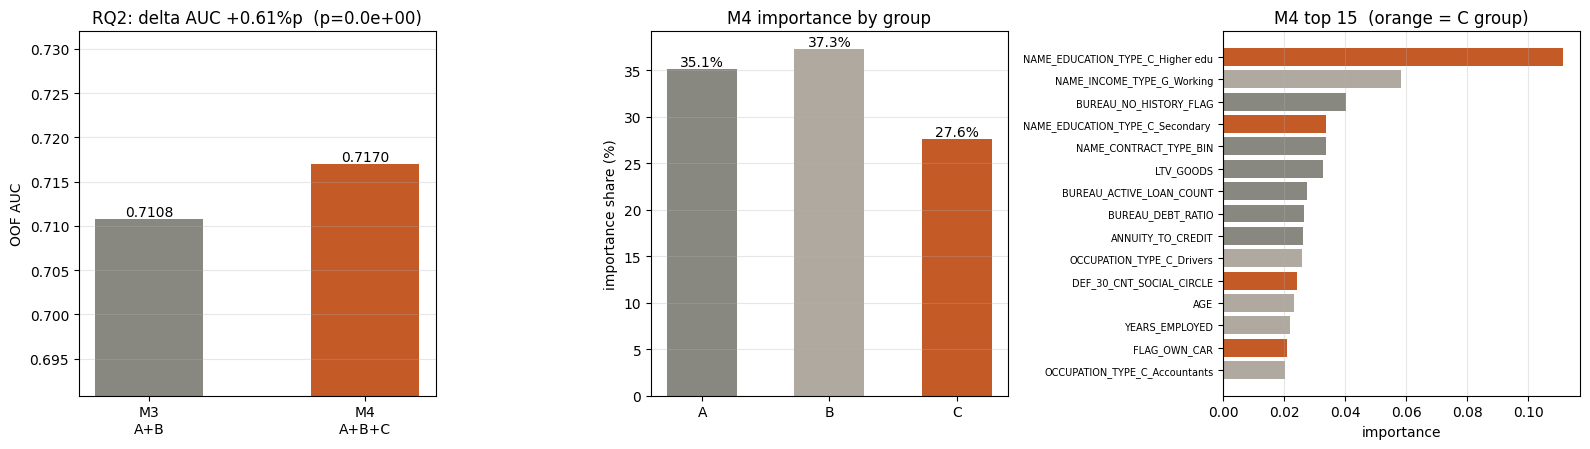

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

# (1) M3 vs M4
b = ax[0].bar(['M3\nA+B', 'M4\nA+B+C'], [auc3, auc4],
              color=['#888780', '#C45A26'], width=.5)
ax[0].bar_label(b, fmt='%.4f', fontsize=10)
lo, hi = min(auc3, auc4), max(auc3, auc4)
ax[0].set_ylim(lo - 0.02, hi + 0.015)
ax[0].set_ylabel('OOF AUC')
ax[0].set_title(f'RQ2: delta AUC {d*100:+.2f}%p  (p={p:.1e})')
ax[0].grid(axis='y', alpha=.3)

# (2) 군별 중요도 비중
idx = [i for i in ['A_금융', 'B_전통비금융', 'C_신규비금융'] if i in g.index]
b = ax[1].bar(['A', 'B', 'C'][:len(idx)], [g.loc[i, '비중(%)'] for i in idx],
              color=['#888780', '#B0A9A0', '#C45A26'][:len(idx)], width=.55)
ax[1].bar_label(b, fmt='%.1f%%', fontsize=10)
ax[1].set_ylabel('importance share (%)')
ax[1].set_title('M4 importance by group')
ax[1].grid(axis='y', alpha=.3)

# (3) 상위 15 — 군별 색
t15 = imp_df.head(15).iloc[::-1]
cmap = {'A_금융': '#888780', 'B_전통비금융': '#B0A9A0', 'C_신규비금융': '#C45A26'}
ax[2].barh(range(len(t15)), t15['중요도'], color=[cmap[v] for v in t15['군']])
ax[2].set_yticks(range(len(t15)))
ax[2].set_yticklabels([v[:32] for v in t15['변수']], fontsize=7)
ax[2].set_xlabel('importance')
ax[2].set_title('M4 top 15  (orange = C group)')
ax[2].grid(axis='x', alpha=.3)

plt.tight_layout(); plt.show()

## 9. 최종 결과

In [11]:
lines = [
    '=' * 62,
    'M4 (A+B+C) — RQ2 검증  |  XGBoost',
    '=' * 62,
    '',
    '■ 모델 (5-fold OOF AUC · seed 42 · EXT 제외)',
    f'   M3 (A+B,   {len(m3_cols):2d})   AUC {auc3:.5f}',
    f'   M4 (A+B+C, {len(m4_cols):2d})   AUC {auc4:.5f}',
    '',
    '■ RQ2 — 은행이 안 쓰는 비금융(C)도 추가로 기여하는가',
    f'   dAUC {d*100:+.2f}%p   DeLong p = {p:.3e}',
    f'   통계유의 {"O" if p < 0.05 else "X"}   실무유의(>=1%p) {"O" if d >= 0.01 else "X"}',
    '',
    '■ M4 군별 중요도',
] + [f'   {i:14s} {g.loc[i, "비중(%)"]:5.1f}%  '
     f'({g.loc[i, "변수수"]:.0f}개, 변수당 {g.loc[i, "변수당"]:.4f})'
     for i in g.index] + [
    '',
    '■ C군(신규비금융) 상세',
    f'   최고 순위  {c_rank}위 / {len(m4_cols)}',
    f'   상위 10위 안  {c_top10}개',
    '',
    '   중요도 상위 5개',
] + [f'      {row["순위"]:2d}위  {row["변수"][:44]:46s} {row["중요도"]:.4f}'
     for _, row in imp_df[imp_df['군'] == 'C_신규비금융'].head(5).iterrows()] + [
    '',
    '■ 해석 주의',
    '   · 중요도는 크기만 나타내며 방향(위험 증가/감소)은 알 수 없다',
    '   · 정보가 겹치는 변수끼리 중요도가 나뉘므로 군별 합계가 개별 순위보다 안정적이다',
    '   · C군은 변수 수가 적어 합계보다 변수당 지표가 공정한 비교다',
    '=' * 62,
]
print('\n'.join(lines))

M4 (A+B+C) — RQ2 검증  |  XGBoost

■ 모델 (5-fold OOF AUC · seed 42 · EXT 제외)
   M3 (A+B,   49)   AUC 0.71083
   M4 (A+B+C, 64)   AUC 0.71697

■ RQ2 — 은행이 안 쓰는 비금융(C)도 추가로 기여하는가
   dAUC +0.61%p   DeLong p = 0.000e+00
   통계유의 O   실무유의(>=1%p) X

■ M4 군별 중요도
   A_금융            35.1%  (18개, 변수당 0.0195)
   B_전통비금융         37.3%  (31개, 변수당 0.0120)
   C_신규비금융         27.6%  (15개, 변수당 0.0184)

■ C군(신규비금융) 상세
   최고 순위  1위 / 64
   상위 10위 안  2개

   중요도 상위 5개
       1위  NAME_EDUCATION_TYPE_C_Higher education         0.1113
       4위  NAME_EDUCATION_TYPE_C_Secondary / secondary    0.0338
      11위  DEF_30_CNT_SOCIAL_CIRCLE                       0.0242
      14위  FLAG_OWN_CAR                                   0.0207
      24위  NAME_EDUCATION_TYPE_C_Lower secondary          0.0133

■ 해석 주의
   · 중요도는 크기만 나타내며 방향(위험 증가/감소)은 알 수 없다
   · 정보가 겹치는 변수끼리 중요도가 나뉘므로 군별 합계가 개별 순위보다 안정적이다
   · C군은 변수 수가 적어 합계보다 변수당 지표가 공정한 비교다


## 10. CSV 저장

셀 출력은 확인용이고, 아래 파일이 실제 산출물이다.

In [12]:
results.to_csv(f'{OUT}/results_M4.csv', index=False, encoding='utf-8-sig')
delong_df.to_csv(f'{OUT}/delong_M4.csv', index=False, encoding='utf-8-sig')
imp_df.to_csv(f'{OUT}/importance_M4_ABC.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({ID: df[ID].values, TARGET: y, 'oof_M3': oof3, 'oof_M4': oof4}) \
  .to_csv(f'{OUT}/oof_xgb_M3M4.csv', index=False)

print(f'저장 완료 -> {OUT}')
for f_, d_ in [('results_M4.csv', results),
               ('delong_M4.csv', delong_df),
               ('importance_M4_ABC.csv', imp_df)]:
    print(f'  {f_:26s} {d_.shape[0]:2d}행 x {d_.shape[1]}열')
print(f'  {"oof_xgb_M3M4.csv":26s} {len(df):,}행')

저장 완료 -> /content/drive/MyDrive/BOOSTMAP/데이터/완료/재계산/모델링
  results_M4.csv              2행 x 4열
  delong_M4.csv               1행 x 5열
  importance_M4_ABC.csv      64행 x 5열
  oof_xgb_M3M4.csv           307,511행


### 산출물 설명

| 파일 | 내용 |
|---|---|
| `results_M4.csv` | M3 · M4 의 변수수 · AUC · 평균트리 |
| `delong_M4.csv` | RQ2 검정 — ΔAUC · p · 유의성 |
| `importance_M4_ABC.csv` | 64행 — 순위 · 변수 · 군 · 중요도 · 비중 |
| `oof_xgb_M3M4.csv` | OOF 예측 — 다른 알고리즘과 비교할 때 사용 |

`oof_xgb_M3M4.csv` 로 알고리즘 간 DeLong 비교를 하려면
같은 fold 분할(`StratifiedKFold(5, shuffle=True, random_state=42)`)을 써야 한다.

### 결과 해석 시 유의사항

**판정 기준** — 두 조건을 모두 봐야 한다.

| 기준 | 내용 |
|---|---|
| 통계유의 | DeLong p < 0.05 |
| 실무유의 | ΔAUC ≥ 0.01 (1%p) |

30만 행에서는 작은 차이도 통계적으로 유의해지므로, p값만으로 판단하면
실질 효과를 과대평가한다. 두 기준이 엇갈릴 경우
**"통계적으로는 유의하나 실무 도입 효과는 제한적"** 으로 기술한다.

**중요도의 한계**

- 크기만 나타내며 **방향(위험 증가 / 감소)은 알 수 없다**
- 정보가 겹치는 변수끼리 값이 나뉘므로 개별 순위보다 군별 합계가 안정적이다
- C군은 변수 수가 적어 합계보다 **변수당** 지표가 공정한 비교다

**변수선정 단계와의 대조**

사전 분석에서 C군 4개 개념그룹의 기여도 합은 0.00849 였다.
이번 ΔAUC 가 그 부근으로 나오면 두 방법이 일치한 것이고,
크게 벗어나면 원인을 확인해야 한다.